Deskripsi singkat terkait projectnya:

membuat machine learning dengan data tersebut untuk mengklasifikasi wilayah-wilayah dengan kategori miskin di indonesia. menggunakan alghoritma kmeans clustering. mungkin output akhirnya si nanti berbentuk maps gitu tapi di warnai atau ditandai dengan warna wilayah-wilayah yang sekiranya kategori paling miskin banget sampai ke miskin aja kek gitu sesuai dengan hasil clusteringan data barunya yang akan di test kan nantinya ke model

Proses cleaning

In [1]:
#import library common like usual
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import data yang akan di proses

#karna format csvku jelek makanya ku kasi delimiter
df = pd.read_csv('/content/Klasifikasi Tingkat Kemiskinan di Indonesia.csv', delimiter=';')

memahami datanya first

In [3]:
#seeing the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Provinsi                                                              514 non-null    object 
 1   Kab/Kota                                                              514 non-null    object 
 2   Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)       514 non-null    object 
 3   Rata-rata Lama Sekolah Penduduk 15+ (Tahun)                           514 non-null    object 
 4   Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)          514 non-null    float64
 5   Indeks Pembangunan Manusia                                            514 non-null    object 
 6   Umur Harapan Hidup (Tahun)                                            514 non-null    object 
 7  

In [4]:
#untuk memastikan kira-kira code mana yang bisa didrop disini
df.nunique()

,0
Provinsi,34
Kab/Kota,514
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),452
Rata-rata Lama Sekolah Penduduk 15+ (Tahun),377
Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),498
Indeks Pembangunan Manusia,452
Umur Harapan Hidup (Tahun),411
Persentase rumah tangga yang memiliki akses terhadap sanitasi layak,487
Persentase rumah tangga yang memiliki akses terhadap air minum layak,465
Tingkat Pengangguran Terbuka,373


dari gambaran di atas terdapat banyak kejanggalan data nama fitur matematis tetapi dtypenya object.

In [5]:
#cek 1 per 1 sebaran datanya
df['Persentase rumah tangga yang memiliki akses terhadap air minum layak'].unique()

array(['87,45', '78,58', '79,65', '86,71', '83,16', '90,10', '94,22',
       '82,36', '89,24', '93,53', '91,09', '95,34', '84,68', '83,12',
       '90,13', '86,36', '89,71', '93,46', '99,37', '96,18', '97,14',
       '94,44', '60,87', '47,79', '73,78', '67,39', '68,81', '89,06',
       '95,04', '94,34', '95,78', '99,74', '91,90', '91,43', '98,18',
       '92,51', '66,21', '91,95', '70,69', '65,64', '98,14', '97,83',
       '77,58', '77,84', '84,66', '86,75', '58,17', '71,52', '92,40',
       '87,20', '99,78', '99,35', '98,80', '99,76', '54,13', '74,11',
       '55,46', '76,23', '78,09', '64,12', '86,50', '86,09', '87,46',
       '68,93', '82,57', '81,01', '70,27', '81,47', '95,52', '96,55',
       '88,27', '98,45', '97,05', '99,43', '97,69', '85,78', '64,84',
       '89,60', '83,61', '93,13', '90,41', '92,17', '93,26', '87,52',
       '88,69', '98,76', '92,86', '74,59', '68,91', '69,96', '73,08',
       '80,66', '85,91', '91,76', '69,97', '73,63', '95,83', '90,55',
       '81,78', '79,

In [6]:
df['Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)'].unique()

array(['18,98', '20,36', '13,18', '13,41', '14,45', '15,26', '18,81',
       '14,05', '19,59', '13,25', '17,43', '16,34', '19,64', '13,34',
       '18,23', '13,23', '19,16', '19,55', '7,61', '15,32', '10,96',
       '11,16', '17,65', '16,82', '9,49', '8,8', '12,67', '9,72', '8,99',
       '8,74', '9,35', '8,81', '8,31', '8,79', '4,01', '10,12', '16,92',
       '9,65', '12,68', '8,3', '12,38', '9,92', '8,69', '8,53', '10,02',
       '25,66', '26,42', '12,33', '13,4', '8,52', '10,3', '8,34', '5,81',
       '7,53', '16,45', '14,84', '7,92', '8,01', '6,8', '4,54', '7,22',
       '6,85', '7,29', '7,48', '7,52', '6,67', '7,51', '4,94', '3,12',
       '2,38', '5,92', '5,14', '6,16', '4,38', '8.97', '6.18', '6,18',
       '9,63', '5,18', '7,82', '10,4', '6,64', '7,18', '25,68', '2,83',
       '3,42', '7,71', '9,11', '8,87', '10,05', '4,53', '11,39', '10,75',
       '6,68', '6,23', '9,02', '3,41', '12,62', '14,68', '12,32', '16,46',
       '13,89', '15,84', '11,12', '10,6', '13,82', '13,35', '1

In [7]:
#cek 1 lagi
df['Rata-rata Lama Sekolah Penduduk 15+ (Tahun)'].unique()

array(['9,48', '8,68', '8,88', '9,67', '8,21', '9,86', '9,55', '10,33',
       '9', '9,29', '8,64', '8,67', '8,4', '8,91', '8,69', '8,71', '10',
       '9,34', '12,83', '11,18', '11,12', '11,11', '8,03', '5,64', '8,63',
       '8,84', '9,99', '10,57', '9,25', '8,8', '9,61', '9,59', '10,1',
       '8,66', '6,06', '9,71', '9,14', '9,44', '8,07', '9,38', '9,02',
       '8,9', '8,41', '6,77', '6,69', '10,41', '9,45', '11,29', '10,44',
       '11,48', '10,94', '11,09', '8,62', '7,2', '8,27', '7,87', '8,12',
       '7,88', '8,97', '8,1', '8,32', '8,55', '11,59', '11,04', '10,32',
       '11,63', '11.34', '10.81', '10.67', '8.75', '8.39', '7,24', '8,7',
       '9,27', '8,54', '9,7', '8,26', '7,84', '11,92', '10,14', '8,56',
       '7,9', '8,04', '8,58', '6,92', '8', '7,59', '8,28', '11,2', '7,05',
       '7,8', '8,52', '7,53', '7,63', '7,44', '7,85', '7,56', '7,64',
       '7,09', '10,75', '9,97', '9,4', '9,9', '8,33', '8,09', '8,38',
       '8,3', '8,18', '8,29', '7,48', '11,8', '7,34', '7,7

oke dtype object tapi beberapa data yang kita gunakan ternyata isinya angka nih. jadi kita ubah aja dtype menjadi int or float depends on the data

In [8]:
df['Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)'] = df['Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)'].str.replace(',', '.').astype(float)
df['Rata-rata Lama Sekolah Penduduk 15+ (Tahun)'] = df['Rata-rata Lama Sekolah Penduduk 15+ (Tahun)'].str.replace(',', '.').astype(float)
df['Indeks Pembangunan Manusia'] = df['Indeks Pembangunan Manusia'].str.replace(',', '.').astype(float)
df['Umur Harapan Hidup (Tahun)'] = df['Umur Harapan Hidup (Tahun)'].str.replace(',', '.').astype(float)
df['Persentase rumah tangga yang memiliki akses terhadap sanitasi layak'] = df['Persentase rumah tangga yang memiliki akses terhadap sanitasi layak'].str.replace(',', '.').astype(float)
df['Persentase rumah tangga yang memiliki akses terhadap air minum layak'] = df['Persentase rumah tangga yang memiliki akses terhadap air minum layak'].str.replace(',', '.').astype(float)
df['Tingkat Pengangguran Terbuka'] = df['Tingkat Pengangguran Terbuka'].str.replace(',', '.').astype(float)
df['Tingkat Partisipasi Angkatan Kerja'] = df['Tingkat Partisipasi Angkatan Kerja'].str.replace(',', '.').astype(float)

In [9]:
#cek perubahan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Provinsi                                                              514 non-null    object 
 1   Kab/Kota                                                              514 non-null    object 
 2   Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)       514 non-null    float64
 3   Rata-rata Lama Sekolah Penduduk 15+ (Tahun)                           514 non-null    float64
 4   Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)          514 non-null    float64
 5   Indeks Pembangunan Manusia                                            514 non-null    float64
 6   Umur Harapan Hidup (Tahun)                                            514 non-null    float64
 7  

In [10]:
#cek jumlah nilai unique didalam variabel klasifikasi kemiskinan
df['Klasifikasi Kemiskinan'].value_counts()

,count
Klasifikasi Kemiskinan,
0.0,452
1.0,62


In [11]:
df.dropna(subset=['Klasifikasi Kemiskinan'], inplace=True)
df['Klasifikasi Kemiskinan'] = df['Klasifikasi Kemiskinan'].astype(int)

In [12]:
#cek kembali
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514 entries, 0 to 513
Data columns (total 13 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Provinsi                                                              514 non-null    object 
 1   Kab/Kota                                                              514 non-null    object 
 2   Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)       514 non-null    float64
 3   Rata-rata Lama Sekolah Penduduk 15+ (Tahun)                           514 non-null    float64
 4   Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)          514 non-null    float64
 5   Indeks Pembangunan Manusia                                            514 non-null    float64
 6   Umur Harapan Hidup (Tahun)                                            514 non-null    float64
 7   Pers

In [13]:
#save to csv
df.to_csv('klasifikasi kemiskinan.csv')

missing value handling

In [14]:
#missing value see
df.isnull().sum()

,0
Provinsi,0
Kab/Kota,0
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),0
Rata-rata Lama Sekolah Penduduk 15+ (Tahun),0
Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),0
Indeks Pembangunan Manusia,0
Umur Harapan Hidup (Tahun),0
Persentase rumah tangga yang memiliki akses terhadap sanitasi layak,0
Persentase rumah tangga yang memiliki akses terhadap air minum layak,0
Tingkat Pengangguran Terbuka,0


In [15]:
#hapus seluruh data yang missing value pada semua kolom
df = df.dropna()

In [16]:
#checking hasil
df.isnull().sum()

,0
Provinsi,0
Kab/Kota,0
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),0
Rata-rata Lama Sekolah Penduduk 15+ (Tahun),0
Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),0
Indeks Pembangunan Manusia,0
Umur Harapan Hidup (Tahun),0
Persentase rumah tangga yang memiliki akses terhadap sanitasi layak,0
Persentase rumah tangga yang memiliki akses terhadap air minum layak,0
Tingkat Pengangguran Terbuka,0


In [17]:
#checking info datanya
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514 entries, 0 to 513
Data columns (total 13 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Provinsi                                                              514 non-null    object 
 1   Kab/Kota                                                              514 non-null    object 
 2   Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)       514 non-null    float64
 3   Rata-rata Lama Sekolah Penduduk 15+ (Tahun)                           514 non-null    float64
 4   Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)          514 non-null    float64
 5   Indeks Pembangunan Manusia                                            514 non-null    float64
 6   Umur Harapan Hidup (Tahun)                                            514 non-null    float64
 7   Pers

In [18]:
df.to_csv('klasifikasi kemiskinan_missing clean.csv', index=False)

okee data sudah bersih dari missing value

checking uplicated data

In [19]:
#duplicate check
df.duplicated().sum()

np.int64(0)

termasuk aman ya karna ngga ada kolom id (terhitung tanpa duplicated)

outliers checking

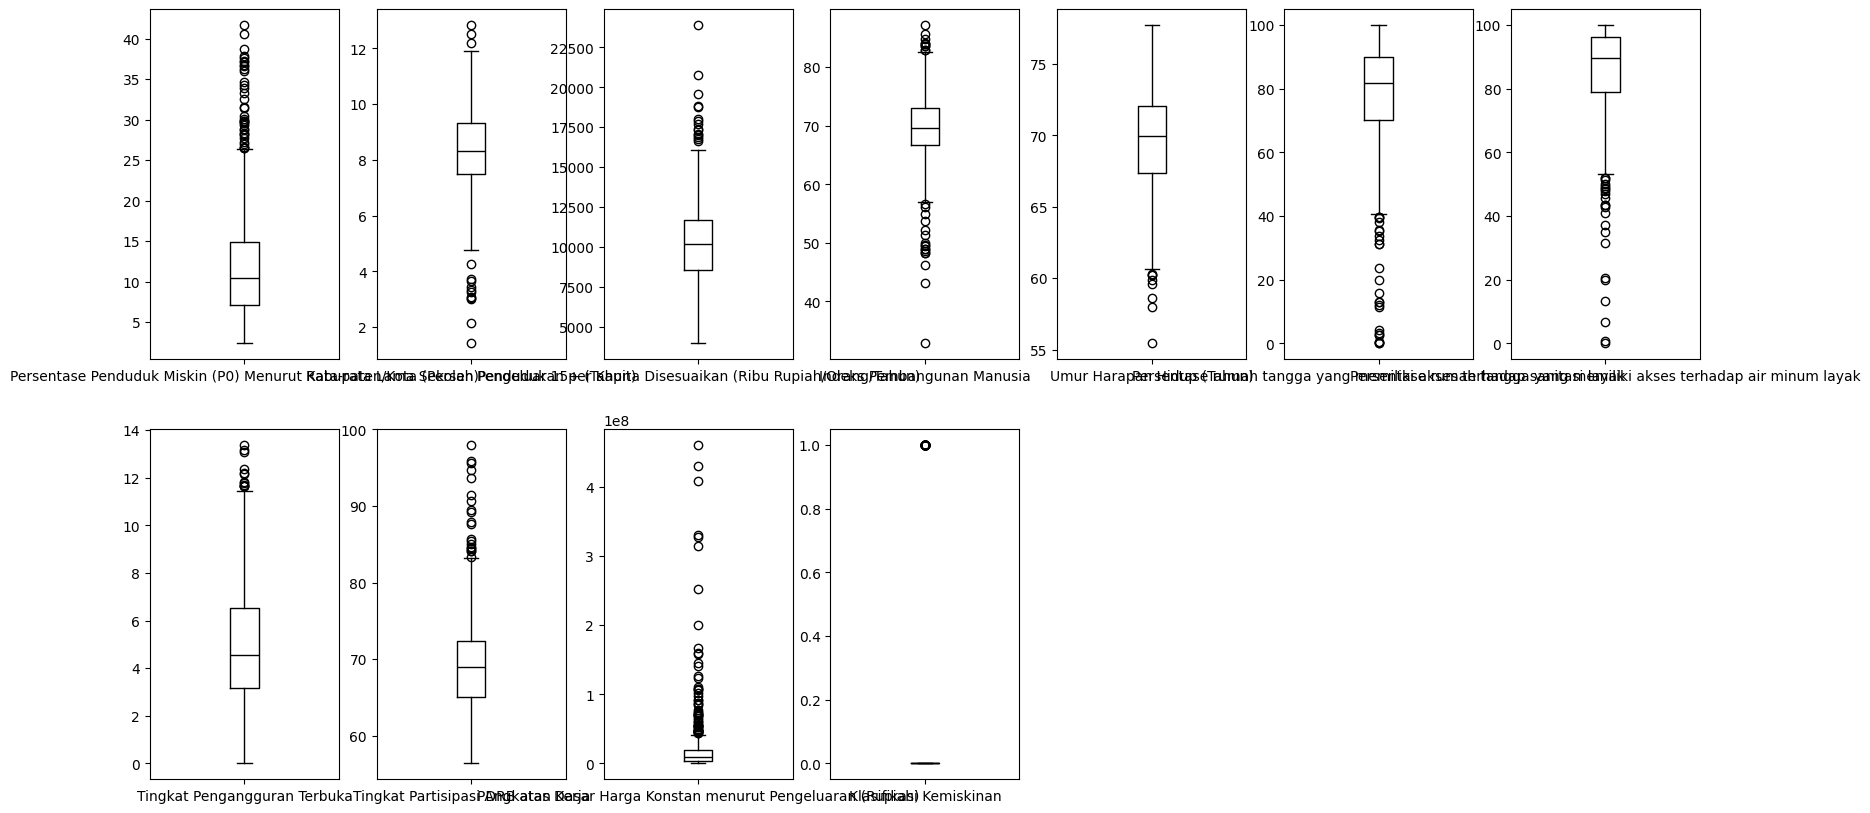

In [20]:
#check outliers data dan rotate gambarnya supaya bisa dilihat dengan jelas
df.plot(kind = 'box', subplots = True, layout = (2,7), sharex = False, sharey = False, figsize = (20, 10), color = 'k')
plt.show()

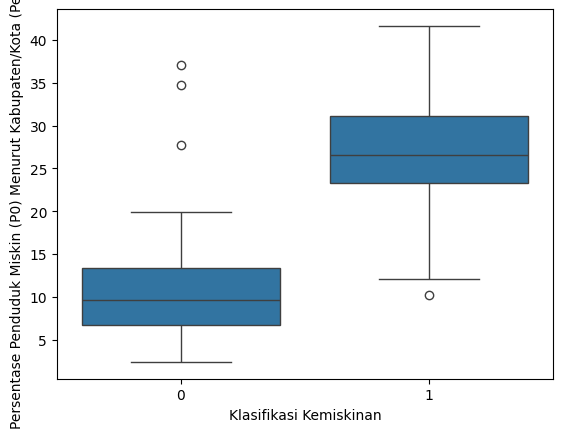

In [21]:
# Menampilkan data berdasarkan target untuk feature chol
sns.boxplot(x='Klasifikasi Kemiskinan', y='Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)', data=df)
plt.show()

#drop outliersnya

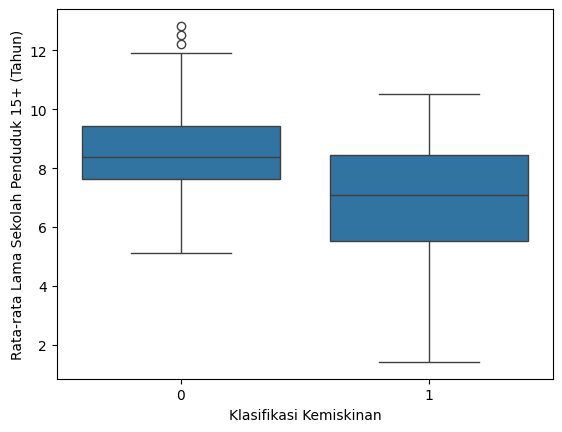

In [22]:
#menampilkan juga data berikutnya
sns.boxplot(x='Klasifikasi Kemiskinan', y='Rata-rata Lama Sekolah Penduduk 15+ (Tahun)', data=df)
plt.show()

#data benar hal ini ditunjukan orang rata-rata sekolah di atas 12 tahun tergolong ngga miskin (masuk akal)

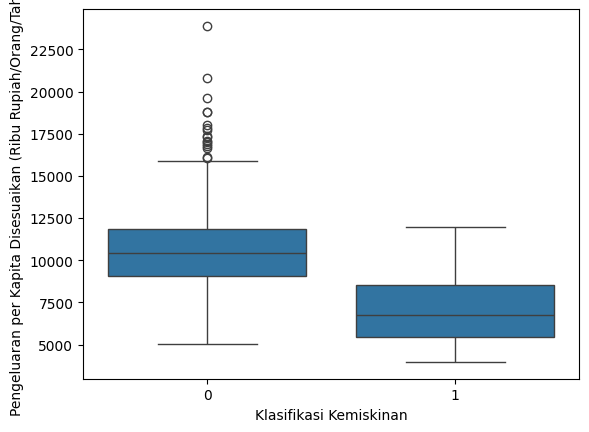

In [23]:
#menampilkan juga data berikutnya
sns.boxplot(x='Klasifikasi Kemiskinan', y='Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)', data=df)
plt.show()

#bagus insightnya

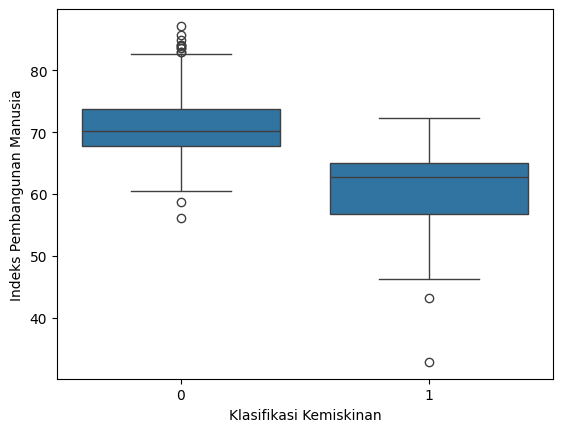

In [24]:
#menampilkan juga data berikutnya
sns.boxplot(x='Klasifikasi Kemiskinan', y='Indeks Pembangunan Manusia', data=df)
plt.show()

#bagus insightnya

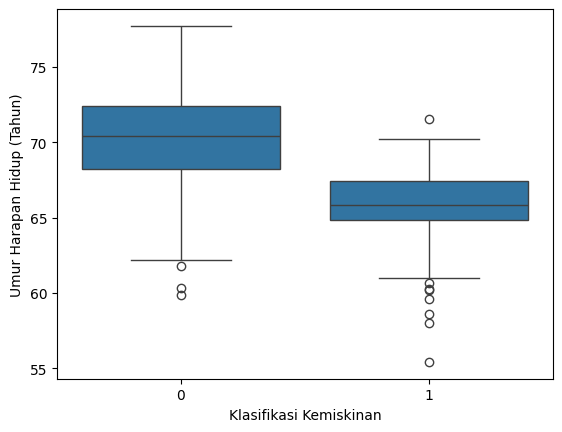

In [25]:
#menampilkan juga data berikutnya
sns.boxplot(x='Klasifikasi Kemiskinan', y='Umur Harapan Hidup (Tahun)', data=df)
plt.show()

#insight bagus

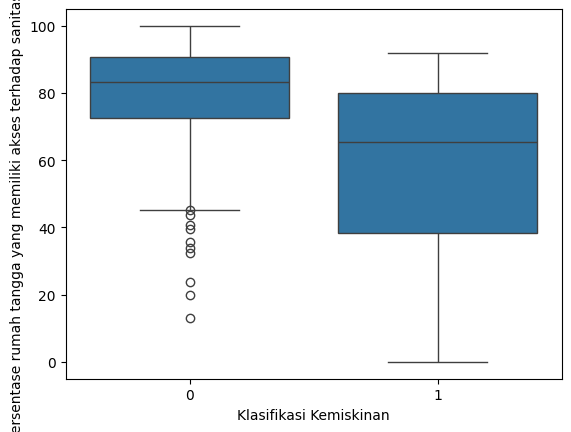

In [26]:
#menampilkan juga data berikutnya
sns.boxplot(x='Klasifikasi Kemiskinan', y='Persentase rumah tangga yang memiliki akses terhadap sanitasi layak', data=df)
plt.show()

#drop outliers

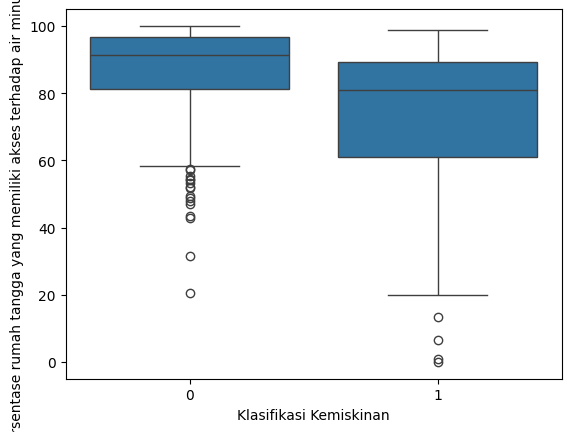

In [27]:
#menampilkan juga data berikutnya
sns.boxplot(x='Klasifikasi Kemiskinan', y='Persentase rumah tangga yang memiliki akses terhadap air minum layak', data=df)
plt.show()

#buang outliers

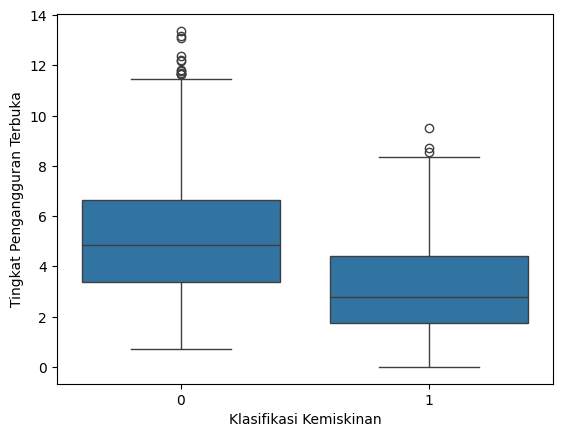

In [28]:
#menampilkan juga data berikutnya
sns.boxplot(x='Klasifikasi Kemiskinan', y='Tingkat Pengangguran Terbuka', data=df)
plt.show()

#drop

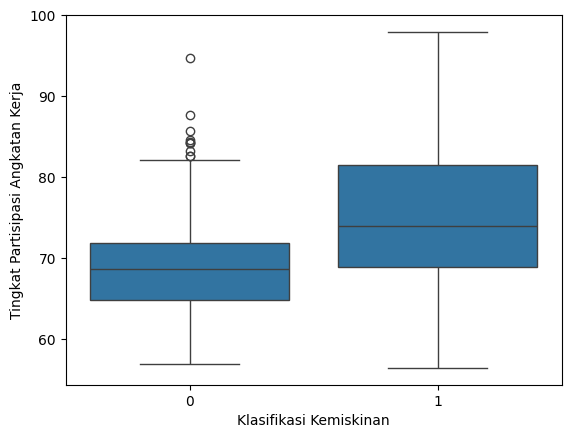

In [29]:
#menampilkan juga data berikutnya
sns.boxplot(x='Klasifikasi Kemiskinan', y='Tingkat Partisipasi Angkatan Kerja', data=df)
plt.show()

#drop

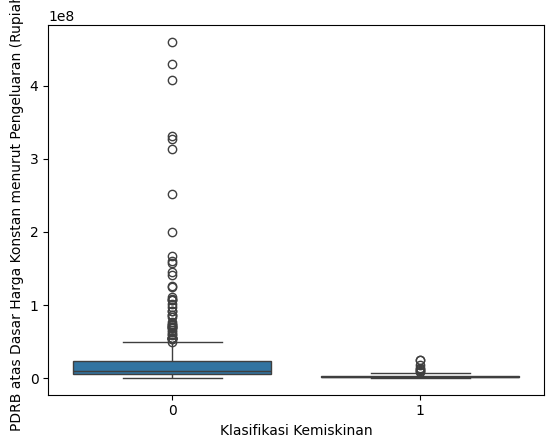

In [30]:

sns.boxplot(x='Klasifikasi Kemiskinan', y='PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)', data=df)
plt.show()

#di kapping winsorize

In [31]:
#eksekusi outliers
#Mencari tahu data yang outliers dengan mendefinisikan fungsi
def outliers(data_out, drop = False):
    outliers_indices_list = []
    for each_feature in data_out.columns:
        feature_data = data_out[each_feature]
        Q1 = np.percentile(feature_data, 25.)
        Q3 = np.percentile(feature_data, 75.)
        IQR = Q3-Q1
        outlier_step = IQR * 1.5
        outliers = feature_data[~((feature_data >= Q1 - outlier_step) & (feature_data <= Q3 + outlier_step))].index.tolist()
        if not drop:
            print('For the feature {}, Num of Outliers is {}'.format(each_feature, len(outliers)))
        if drop:
            df.drop(outliers, inplace = True, errors = 'ignore')
            print('Outliers from {} feature removed'.format(each_feature))
    return outliers_indices_list

In [32]:
#hapus beberapa fitur outliers yang sudah di seleksi tadi ya
outliers(df[['Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)', 'Persentase rumah tangga yang memiliki akses terhadap sanitasi layak', 'Persentase rumah tangga yang memiliki akses terhadap air minum layak', 'Tingkat Pengangguran Terbuka', 'Tingkat Partisipasi Angkatan Kerja']])

For the feature Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen), Num of Outliers is 36
For the feature Persentase rumah tangga yang memiliki akses terhadap sanitasi layak, Num of Outliers is 25
For the feature Persentase rumah tangga yang memiliki akses terhadap air minum layak, Num of Outliers is 23
For the feature Tingkat Pengangguran Terbuka, Num of Outliers is 12
For the feature Tingkat Partisipasi Angkatan Kerja, Num of Outliers is 20


[]

In [33]:
#hapus beberapa fitur outliers yang sudah di seleksi tadi ya
outliers(df[['Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)', 'Persentase rumah tangga yang memiliki akses terhadap sanitasi layak', 'Persentase rumah tangga yang memiliki akses terhadap air minum layak', 'Tingkat Pengangguran Terbuka', 'Tingkat Partisipasi Angkatan Kerja']], drop=True)

Outliers from Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen) feature removed
Outliers from Persentase rumah tangga yang memiliki akses terhadap sanitasi layak feature removed
Outliers from Persentase rumah tangga yang memiliki akses terhadap air minum layak feature removed
Outliers from Tingkat Pengangguran Terbuka feature removed
Outliers from Tingkat Partisipasi Angkatan Kerja feature removed


[]

In [34]:
#winsorize untuk fitur PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)
from scipy.stats.mstats import winsorize
col = 'PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)'

df[col] = winsorize(
    df[col],
    limits=[0.01, 0.01]
)

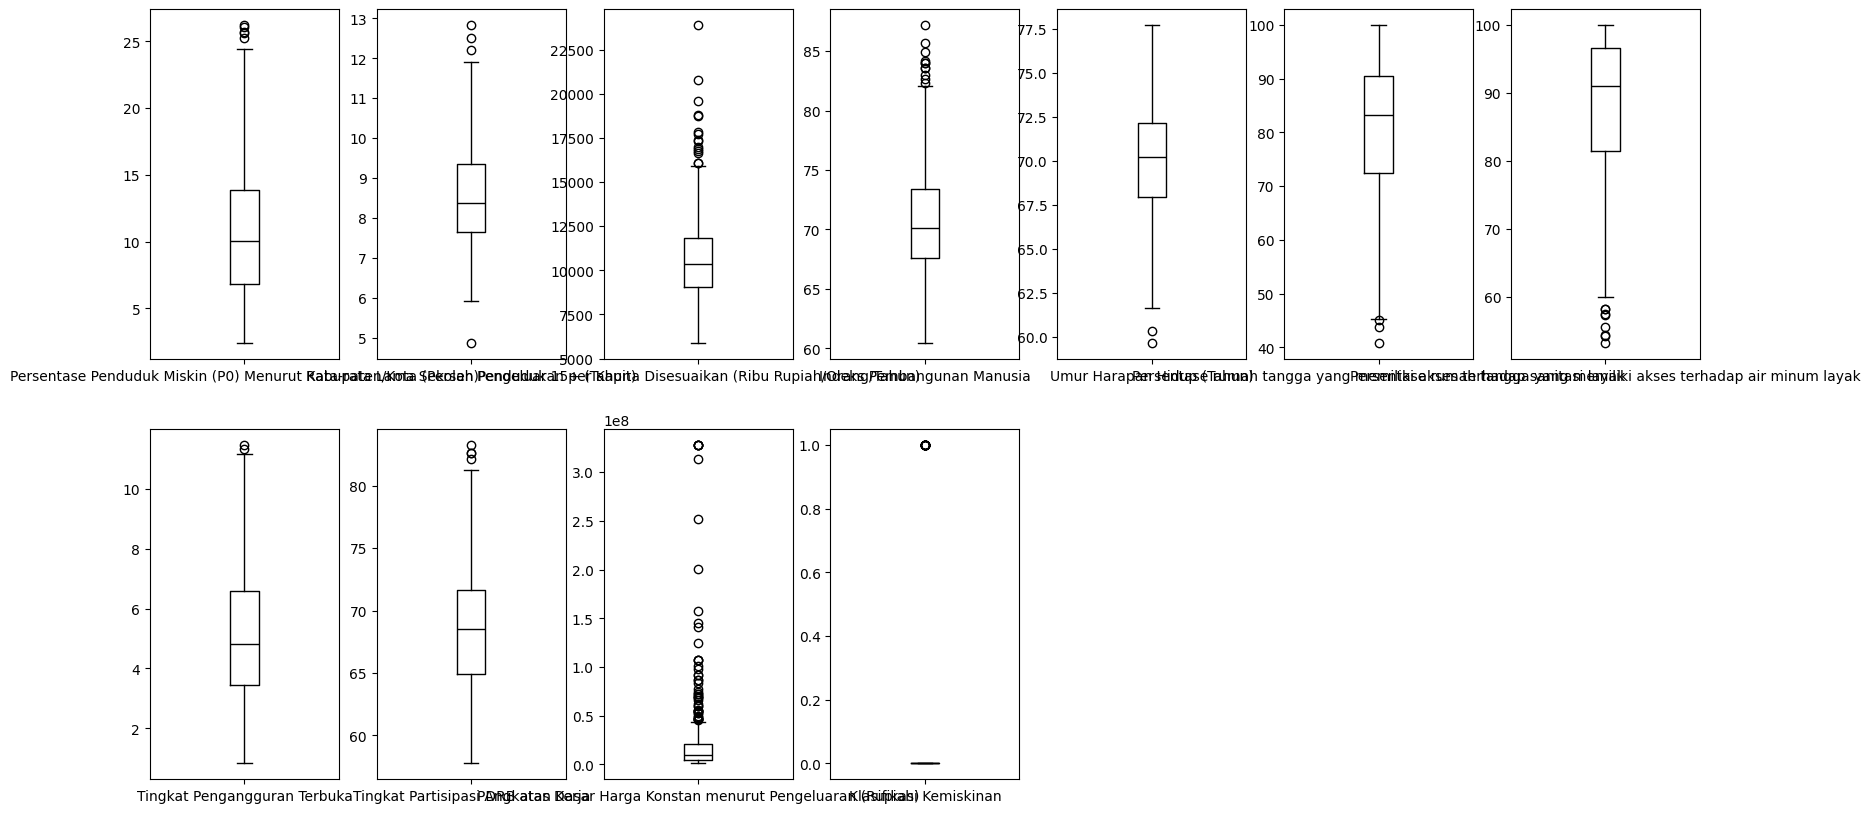

In [35]:
#cek ulang hasilnya
df.plot(kind = 'box', subplots = True, layout = (2,7), sharex = False, sharey = False, figsize = (20, 10), color = 'k')
plt.show()

scaling

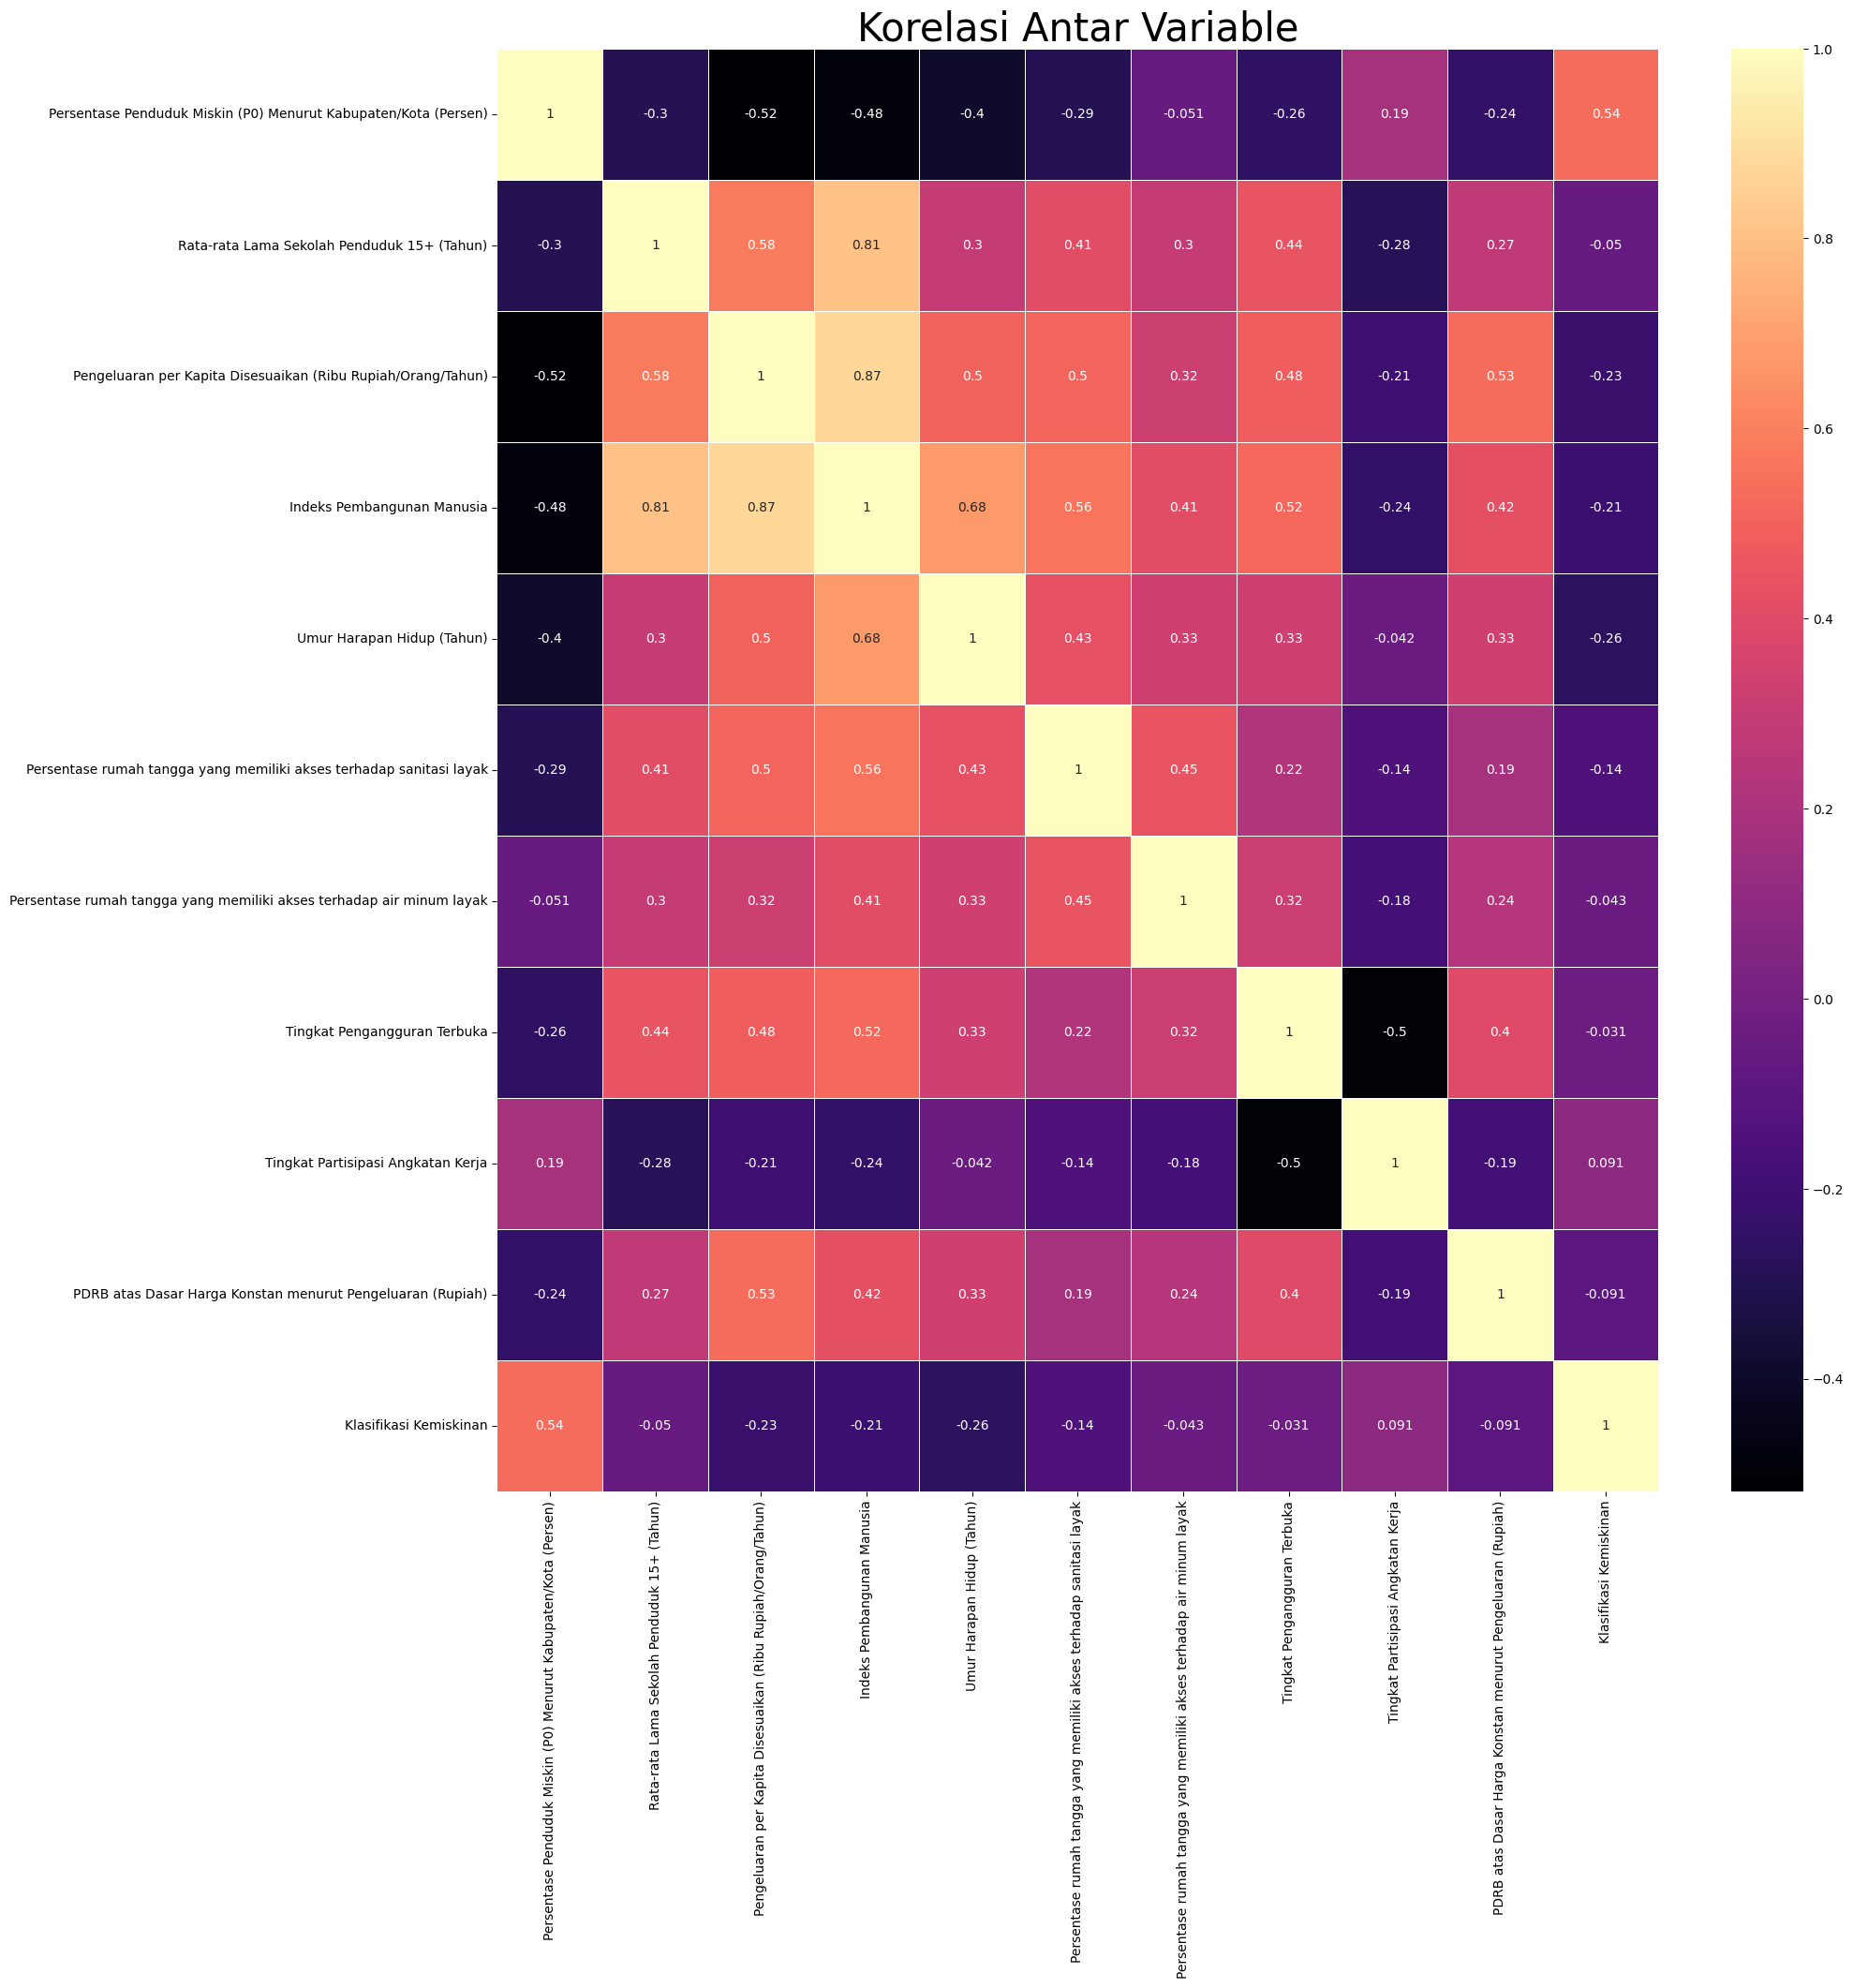

In [50]:
import numpy as np
# melihat korelasi antar variable untuk mencari feature yang penting
plt.figure(figsize=(20,20))
# Exclude non-numeric columns like 'Provinsi', 'Kab/Kota', and 'Cluster' from correlation calculation
cor = df.drop(columns=['Provinsi', 'Kab/Kota', 'Cluster'], errors='ignore').corr(numeric_only=True)
sns.heatmap(cor,annot=True, linewidth=.5, cmap="magma")
plt.title('Korelasi Antar Variable', fontsize = 30)
plt.show()

In [51]:
#patenkan fiturfitur yang dipakai
features = [
    'Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',
    'Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)',
    'Umur Harapan Hidup (Tahun)'
]

X = df[features]

In [52]:
#scaling data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [53]:
#lihat tampilan data after scaling
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.describe()

,Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),Umur Harapan Hidup (Tahun)
count,443.000000,443.000000,443.000000
mean,0.348923,0.267740,0.575309
std,0.210488,0.136330,0.173804
min,0.000000,0.000000,0.000000
25%,0.186110,0.175736,0.460519
50%,0.321024,0.249958,0.584760
75%,0.482375,0.330754,0.693539
max,1.000000,1.000000,1.000000


modeling

In [54]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#elbow method for menentukan jumlah cluster terbaik
inertia = []

K_range = range(1, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

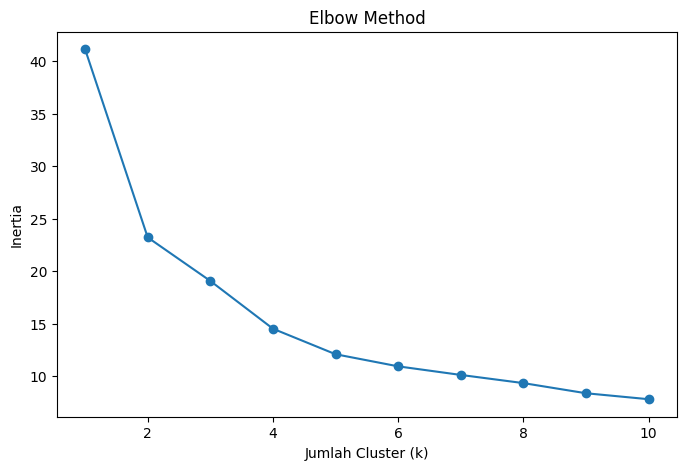

In [55]:
#visualisasi elbow method
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [74]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"k={k}, score={score}")

k=2, score=0.3797491900938593
k=3, score=0.2628706932963439
k=4, score=0.29848669946379797
k=5, score=0.3013596444458256
k=6, score=0.2800754499299304
k=7, score=0.24449804539779085
k=8, score=0.23339891667340096
k=9, score=0.2511472070079947
k=10, score=0.24210866526138453


In [66]:
#membuat model k-means
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

In [67]:
# training + hasil cluster
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [68]:
#lihat hasil clusternya
print(df[['Provinsi', 'Kab/Kota', 'Cluster']].head())

  Provinsi       Kab/Kota  Cluster
0     ACEH       Simeulue        1
1     ACEH   Aceh Singkil        1
2     ACEH   Aceh Selatan        1
3     ACEH  Aceh Tenggara        1
4     ACEH     Aceh Timur        1


In [69]:
#rata-rata tiap cluster
cluster_summary = df.groupby('Cluster')[features].mean()

print(cluster_summary)

         Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)  \
Cluster                                                                    
0                                                 7.616384                 
1                                                15.545174                 

         Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)  \
Cluster                                                                 
0                                             11668.520295              
1                                              9141.936047              

         Umur Harapan Hidup (Tahun)  
Cluster                              
0                         71.447970  
1                         67.818663  


In [70]:
#lihat scorenya
score = silhouette_score(X_scaled, df['Cluster'])
print('Silhouette Score:', score)

Silhouette Score: 0.3797491900938593


Penyebab score silhouette rendah

Kemungkinan:

- fitur terlalu banyak
- ada fitur kurang relevan (coba kurangi fitur) coba fitur coleration
- outlier masih kuat (cek outliers lagi) done
- scaling belum optimal
- jumlah cluster belum ideal (coba beberapa nilai k)
- data memang overlap alami (coba PCA bot 13)

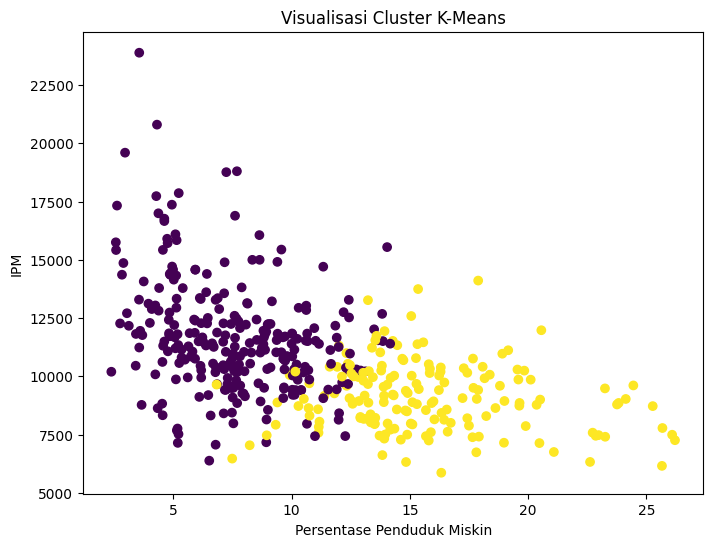

In [71]:
#visualisasi sederhana
plt.figure(figsize=(8,6))

plt.scatter(
    df['Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)'],
    df['Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)'],
    c=df['Cluster']
)

plt.xlabel('Persentase Penduduk Miskin')
plt.ylabel('IPM')
plt.title('Visualisasi Cluster K-Means')

plt.show()

In [72]:
#melihat daerah percluster
for i in sorted(df['Cluster'].unique()):

    print(f"\n===== CLUSTER {i} =====")

    display(
        df[df['Cluster'] == i][
            ['Provinsi', 'Kab/Kota']
        ].head(10)
    )


===== CLUSTER 0 =====


,Provinsi,Kab/Kota
18,ACEH,Kota Banda Aceh
20,ACEH,Kota Langsa
21,ACEH,Kota Lhokseumawe
27,SUMATERA UTARA,Tapanuli Utara
28,SUMATERA UTARA,Toba Samosir
29,SUMATERA UTARA,Labuhan Batu
30,SUMATERA UTARA,Asahan
31,SUMATERA UTARA,Simalungun
34,SUMATERA UTARA,Deli Serdang
35,SUMATERA UTARA,Langkat



===== CLUSTER 1 =====


,Provinsi,Kab/Kota
0,ACEH,Simeulue
1,ACEH,Aceh Singkil
2,ACEH,Aceh Selatan
3,ACEH,Aceh Tenggara
4,ACEH,Aceh Timur
5,ACEH,Aceh Tengah
6,ACEH,Aceh Barat
7,ACEH,Aceh Besar
8,ACEH,Pidie
9,ACEH,Bireuen
